# Neural Network from Scratch


## Import Libraries


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


## Load Dataset


In [2]:
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
y = y.reshape(-1, 1)


## Preprocessing


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Model Implementation


In [4]:
class NeuralNetwork:
    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.1):
        self.lr = learning_rate
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.1
        self.b2 = np.zeros((1, output_dim))
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, a):
        return a * (1 - a)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2

    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

    def backward(self, X, y_true):
        m = X.shape[0]
        dZ2 = self.A2 - y_true
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        dZ1 = np.dot(dZ2, self.W2.T) * self.sigmoid_derivative(self.A1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)
            self.backward(X, y)

    def predict(self, X):
        probabilities = self.forward(X)
        return (probabilities >= 0.5).astype(int)


## Model Training


In [5]:
np.random.seed(42)
model = NeuralNetwork(input_dim=2, hidden_dim=4, output_dim=1, learning_rate=0.5)
model.train(X_train, y_train, epochs=1000)


## Prediction


In [6]:
y_pred = model.predict(X_test)


## Evaluation


In [7]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Final Training Loss: {model.losses[-1]:.4f}")
print(f"Testing Accuracy: {accuracy:.4f}")


Final Training Loss: 0.2999
Testing Accuracy: 0.8667


## Visualization


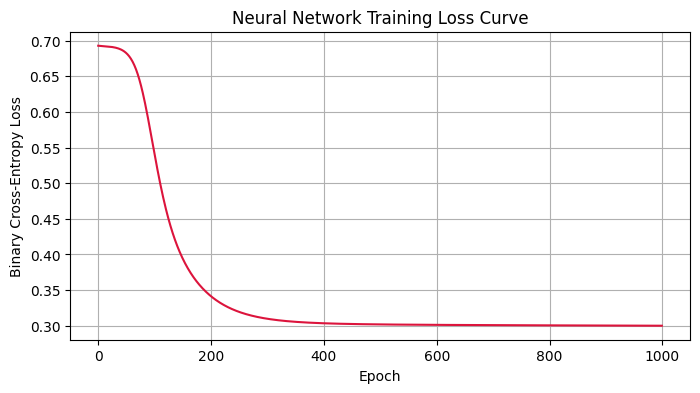

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(model.losses, color="crimson")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Neural Network Training Loss Curve")
plt.grid(True)
plt.show()
